In [1]:
%load_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
from mylib.plot import plot_imgs
from losses.dt_loss import *

edges1 shape: torch.Size([64, 2]), edges2 shape: torch.Size([64, 2])


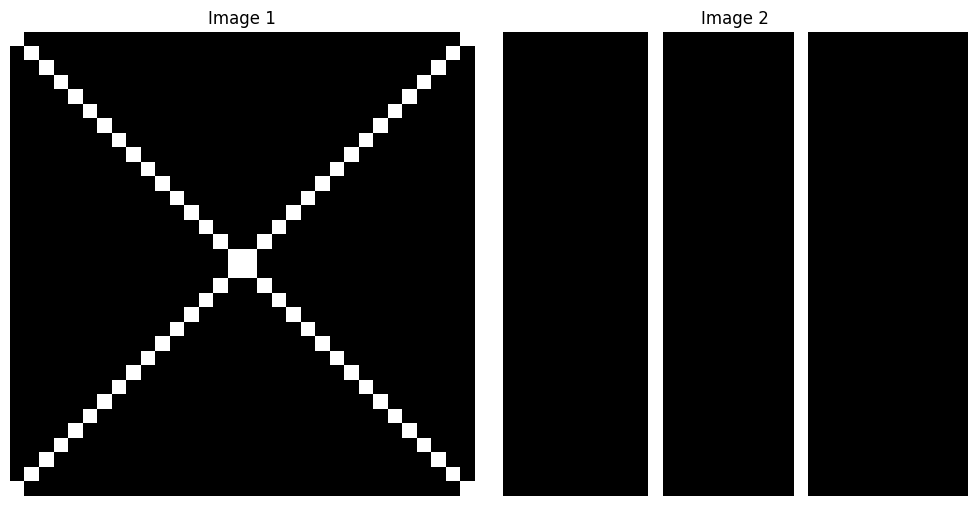

In [28]:
import torch
import matplotlib.pyplot as plt
from mylib.plot import plot_imgs
from losses.dt_loss import *

size = 32
edges1_map = torch.eye(size) + torch.flip(torch.eye(size), dims=(1,))
edges2_map = torch.zeros(size, size)

# draw some simple edges FIRST
edges2_map[:, size//3] = 1       # vertical line
edges2_map[:, size//3*2] = 1       # vertical line


# THEN extract coordinates
edges1 = edges1_map.nonzero().flip(dims=(1,))
edges2 = edges2_map.nonzero().flip(dims=(1,))

print(f"edges1 shape: {edges1.shape}, edges2 shape: {edges2.shape}")

plot_imgs([edges1_map.squeeze().cpu(), edges2_map.squeeze().cpu()], cmap="gray")

In [29]:
from losses.dt_loss import compute_distance_field, sample_distance_field

field2 = compute_distance_field(edges2_map)
dist = sample_distance_field(field2, edges1).cpu()

# field2, dist, edges1

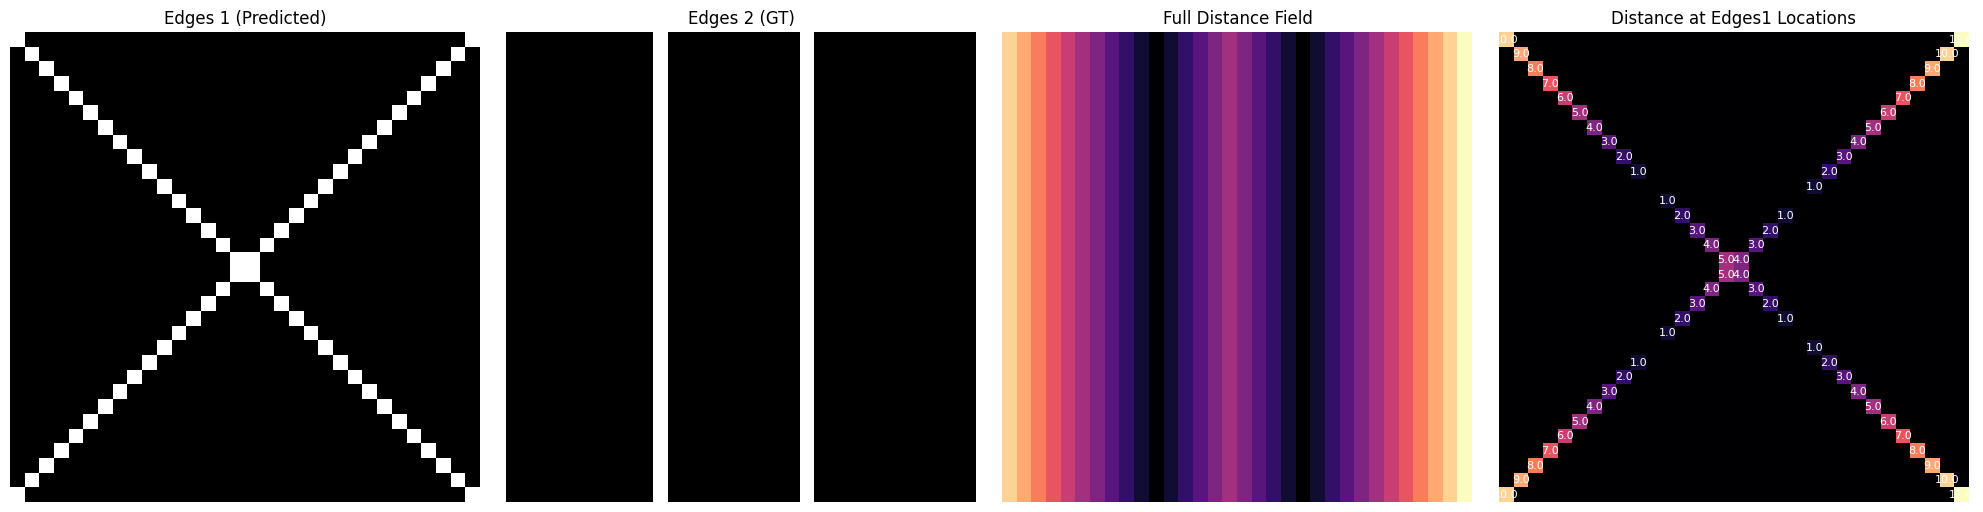

In [31]:
# Visualization showing distance field only at edges1 locations
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Show edges1 (predicted)
axes[0].imshow(edges1_map.squeeze().cpu(), cmap="gray")
axes[0].set_title("Edges 1 (Predicted)")
axes[0].axis('off')

# Show edges2 (target/GT)
axes[1].imshow(edges2_map.squeeze().cpu(), cmap="gray")
axes[1].set_title("Edges 2 (GT)")
axes[1].axis('off')

# Full distance field
im2 = axes[2].imshow(field2.squeeze().cpu(), cmap="magma")
axes[2].set_title("Full Distance Field")
axes[2].axis('off')
# plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# Create the masked distance field at edges1 locations
mfield = torch.zeros_like(field2).cpu()
for pt, d in zip(edges1.long(), dist):
    mfield[pt[1], pt[0]] = d  # FIX: pt is (x,y), tensor needs [y,x]

im3 = axes[3].imshow(mfield, cmap="magma")
axes[3].set_title("Distance at Edges1 Locations")
axes[3].axis('off')
# plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

# plot values in cells given edges1
mfield_np = mfield.numpy()
for row in range(size):
    for col in range(size):
        if mfield_np[row, col] > 0:  # Changed condition to > 0
            axes[3].text(col, row, f"{mfield_np[row, col]:.1f}",
                        ha='center', va='center', color='white', fontsize=8)

plt.tight_layout()
plt.show()